# Worksheet-5 Solution
## Implementation of Convolutional Neural Network using Keras

**Module:** Artificial Intelligence and Machine Learning  
**Institution:** Herald College Kathmandu  
**Submitted Date:** April 02, 2026

---

### Student Details

| Name | ID Number | Group |
| :--- | :--- | :--- |
| **Narayan Lohani** | 2408869 | L6CG15 |

---

<div style="display: flex; justify-content: space-between; align-items: center; border: none;">
  <img src="https://heraldcollege.edu.np/images/footer/footer-logo-dark.svg" width="180" alt="Herald College Logo">
  <img src="
  https://bizzeducation.com/storage/university-partners/May2024/r3iG0n8CHfh1nCAIz5BO.png" width="180" alt="University of Wolverhampton Logo">
</div>


### 7 Exercise

Implement an End to End CNN Model for Image Classification Task.

### Objective

In this exercise, you will build and train a Convolutional Neural Network to classify fruits in Amazon using TensorFlow and Keras.


In [ ]:
import tensorflow as tf
import keras
import numpy as np

# Verify TensorFlow is correctly installed and display its version
print(f"✅ TensorFlow version: {tf.__version__}")


✅ TensorFlow version: 2.21.0


### Task 1: Data Understanding and Visualization:

Download the Provided Data and Complete the following task.

1.  Load and visualize images from a dataset stored in directories, where each subdirectory represents a class. You are expected to write a code:

    -   Get the list of class directories from the train folder.

    -   Select one image randomly from each class.

    -   Display the images in a grid format with two rows using `matplotlib`.

    -   **Expected Output:** Figure 6: Expected Output.

    -   **What did you Observe?**

In [ ]:
# Set the directory paths for training and testing data
TRAIN_DIR = "FruitinAmazon/train/"
TEST_DIR = "FruitinAmazon/test/"

print("Train dir:", TRAIN_DIR)
print("Test  dir:", TEST_DIR)


Train dir: FruitinAmazon/train/
Test  dir: FruitinAmazon/test/


In [ ]:
import os

# Get sorted list of class directories from the train folder
class_dirs = sorted(
    [
        directory
        for directory in os.listdir(TRAIN_DIR)
        if os.path.isdir(os.path.join(TRAIN_DIR, directory))
    ]
)

print("Classes found:", class_dirs)
num_classes = len(class_dirs)


Classes found: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [ ]:
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

sample_images = {}
class_counts = {}

random.seed(42)

for fruit_class in class_dirs:
    cls_path = os.path.join(TRAIN_DIR, fruit_class)

    images = [
        image_file
        for image_file in os.listdir(cls_path)
        if image_file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    # Store the count for this class
    class_counts[fruit_class] = len(images)

    if images:
        sample_images[fruit_class] = os.path.join(cls_path, random.choice(images))

# Print the total number of samples in each class
print("--- Class Distribution ---")
for fruit_class, count in class_counts.items():
    print(f"{fruit_class}: {count} images")
print(f"Total images: {sum(class_counts.values())}")
print("--------------------------")


--- Class Distribution ---
acai: 15 images
cupuacu: 15 images
graviola: 15 images
guarana: 15 images
pupunha: 15 images
tucuma: 15 images
Total images: 90
--------------------------


In [ ]:
# Printing Metadata for one Sample Image
if sample_images:
    first_class = list(sample_images.keys())[0]
    sample_path = sample_images[first_class]

    with Image.open(sample_path) as img_meta:
        print(f"--- Metadata for Sample: {os.path.basename(sample_path)} ---")
        print(f"Class: {first_class}")
        print(f"Format: {img_meta.format}")
        print(f"Mode: {img_meta.mode}")
        print(f"Size (Width x Height): {img_meta.size}")
        print("-" * 40)


--- Metadata for Sample: images (5).jpeg ---
Class: acai
Format: JPEG
Mode: RGB
Size (Width x Height): (340, 148)
----------------------------------------


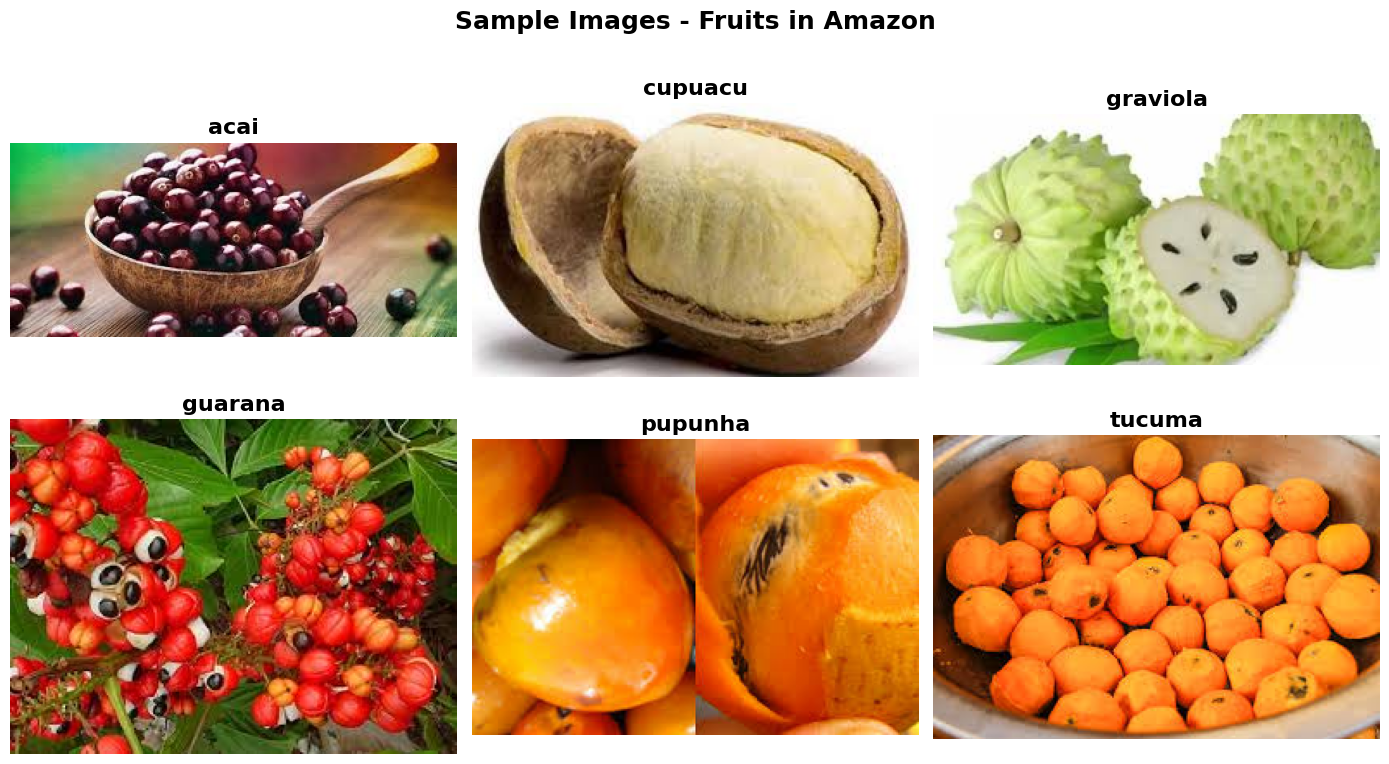

In [ ]:
# Display a sample image of each fruit in a 2-row grid (3 images per row)
cols, rows = 3, 2
fig, axes = plt.subplots(rows, cols, figsize=(14, 8))
axes = axes.flatten()

# Select one random image per class
for idx, (image_class, img_path) in enumerate(sample_images.items()):
    img = mpimg.imread(img_path)
    axes[idx].imshow(img)
    axes[idx].set_title(image_class, fontsize=16, fontweight="bold")
    axes[idx].axis("off")

plt.suptitle("Sample Images - Fruits in Amazon", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()


**Observation**

* The dataset 6 classes of Amazonian fruits: acai, cupuacu, graviola, guarana, pupunha, tucuma

* There are only 15 images per class, which is very few for training, meaning the model can be at the risk of overfitting.
---

**2. Check for Corrupted Image:** Write a script that verifies whether the image in the train directory are valid. If any corrupted images are found, the script must remove the image from the directory and print the message which image have been removed, if none found print "No Corrupted Images Found."

-   **Hint:**

    -   Iterate through each class subdirectory and check if each image is valid.

    -   Use the `Image.open()` function to attempt to load each image.

    -   If the image is corrupted i.e. raises an `IOError` or `SyntaxError`, remove the image from the directory and `print(f"Removed corrupted image: {image_path})"`.

    -   Maintain a list of all corrupted image paths for reporting.

-   **Expected Output:** No corrupted images found.

In [ ]:
from PIL import Image

corrupted = []

for fruit_class in class_dirs:
    fruit_class_path = os.path.join(TRAIN_DIR, fruit_class)
    for fname in os.listdir(fruit_class_path):
        img_path = os.path.join(fruit_class_path, fname)
        try:
            with Image.open(img_path) as img:
                img.verify()  # verify integrity
        except (IOError, SyntaxError):
            corrupted.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if not corrupted:
    print("No Corrupted Images Found.")
else:
    print(f"\nTotal corrupted images removed: {len(corrupted)}")


No Corrupted Images Found.


### Task 2: Loading and Preprocessing Image Data in keras:

In [ ]:
# Hyper-parameters
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 16
VALIDATION_SPLIT = 0.2
SEED = 123

# Normalisation layer: scale pixel values to [0, 1]
rescale = tf.keras.layers.Rescaling(1.0 / 255)

# ── Training dataset ──────────────────────────────────────────────────────────
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation="nearest",
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
)

# ── Class names ───────────────────────────────────────────────────────────────
class_names = train_ds.class_names
print("Class names :", class_names)

num_classes = len(class_names)
print("Num classes :", num_classes)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# ── Validation dataset ────────────────────────────────────────────────────────
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation="nearest",
    batch_size=BATCH_SIZE,
    shuffle=False,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
)
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

# ── Test dataset ──────────────────────────────────────────────────────────────
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="int",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation="nearest",
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED,
)
test_ds = test_ds.map(lambda x, y: (rescale(x), y))


Found 90 files belonging to 6 classes.
Using 72 files for training.
Class names : ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Num classes : 6
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.


### Task 3 - Implement a CNN with

Follow the following Structure and Hyper - parameters:

**Convolutional Architecture:**

-   **Convolutional Layer 1:**

    -   Filter Size (F): (3, 3)

    -   Number of Filters (k): 32

    -   Padding (P): same

    -   Stride (s): 1

-   **Activation Layer:** ReLU activation

-   **Pooling Layer 1:** Max pooling

    -   Filter Size (F): (2, 2)

    -   Stride (s): 2

-   **Convolutional Layer 2:**

    -   Filter Size (F): (3, 3)

    -   Number of Filters (k): 32

    -   Padding (P): same

    -   Stride (s): 1

-   **Activation Layer:** ReLU activation

-   **Pooling Layer 2:** Max pooling

    -   Filter Size (F): (2, 2)

    -   Stride (s): 2

**Fully Connected Network Architecture:**

-   **Flatten Layer:** Flatten the input coming from the convolutional layers

-   **Input Layer:**

-   **Hidden Layer - 2:**

    -   Number of Neurons: 64

    -   Number of Neurons: 128

-   **Output Layer:**

    -   Number of Neurons: num classes (number of output classes)

In [ ]:
from keras import layers

model = keras.Sequential(
    [
        layers.Input(
            shape=(IMG_HEIGHT, IMG_WIDTH, 3),
        ),
        # ── Convolutional Block 1 ───────────────────────────────────────────
        layers.Conv2D(
            filters=32,
            kernel_size=(3, 3),
            strides=(1, 1),
            padding="same",
            activation="relu",
            name="conv2d_1",
        ),
        layers.MaxPooling2D(pool_size=(2, 2), strides=2, name="maxpool_1"),
        # ── Convolutional Block 2 ───────────────────────────────────────────
        layers.Conv2D(
            filters=32,
            kernel_size=(3, 3),
            strides=(1, 1),
            padding="same",
            activation="relu",
            name="conv2d_2",
        ),
        layers.MaxPooling2D(pool_size=(2, 2), strides=2, name="maxpool_2"),
        # ── Fully Connected Head ────────────────────────────────────────────
        layers.Flatten(name="flatten"),
        layers.Dense(128, activation="relu", name="dense_128"),
        layers.Dense(64, activation="relu", name="dense_64"),
        layers.Dense(num_classes, activation="softmax", name="output"),
    ],
    name="FruitsInAmazon_CNN",
)

model.summary()


Model: "FruitsInAmazon_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling2D)        │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_2 (MaxPooling2D)        │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

### Task 4: Compile the Model

**Model Compilation**

-   Choose an appropriate optimizer (e.g., Adam), loss function (e.g., sparse categorical crossentropy), and evaluation metric (e.g., accuracy).

In [ ]:
# ── Compile ───────────────────────────────────────────────────────────────────
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
print("Model Compiled Successfully!")


Model Compiled Successfully!


### Task 5: Train the Model

**Model Training**

-   Use the `model.fit()` function to train the model. Set the batch size to 16 and the number of epochs to 250.

-   Use `val ds` for validation.

-   Use callbacks such as `ModelCheckpoint` and `EarlyStopping` for saving the best model and avoiding overfitting.

In [ ]:
from keras.callbacks import ModelCheckpoint, EarlyStopping

EPOCHES = 250

# ── Callbacks ─────────────────────────────────────────────────────────────────
checkpoint_cb = ModelCheckpoint(
    filepath="best_fruits_cnn.h5",
    monitor="val_accuracy",
    save_best_only=True,
    save_weights_only=False,
    verbose=1,
)

early_stop_cb = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
    verbose=1,
)

# ── Train ─────────────────────────────────────────────────────────────────────
history = model.fit(
    train_ds,
    epochs=EPOCHES,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    callbacks=[checkpoint_cb, early_stop_cb],
)


Epoch 1/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.1263 - loss: 2.5616
Epoch 1: val_accuracy improved from None to 0.05556, saving model to best_fruits_cnn.h5



Epoch 1: finished saving model to best_fruits_cnn.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - accuracy: 0.1250 - loss: 2.6585 - val_accuracy: 0.0556 - val_loss: 1.6894
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.2316 - loss: 1.7673
Epoch 2: val_accuracy improved from 0.05556 to 0.11111, saving model to best_fruits_cnn.h5



Epoch 2: finished saving model to best_fruits_cnn.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.2778 - loss: 1.7765 - val_accuracy: 0.1111 - val_loss: 1.8834
Epoch 3/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.4531 - loss: 1.6500
Epoch 3: val_accuracy improved from 0.11111 to 0.72222, saving model to best_fruits_cnn.h5



Epoch 3: finished saving model to best_fruits_cnn.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.4722 - loss: 1.6055 - val_accuracy: 0.7222 - val_loss: 1.4476
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.5042 - loss: 1.3564
Epoch 4: val_accuracy did not improve from 0.72222
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 0.5417 - loss: 1.2968 - val_accuracy: 0.6667 - val_loss: 0.9780
Epoch 5/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.6432 - loss: 1.0148
Epoch 5: val_accuracy did not improve from 0.72222
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.6944 - loss: 0.9391 - val_accuracy: 0.6667 - val_loss: 0.8811
Epoch 6/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.8620 - loss: 0.6400
Epoch 6: val_accuracy did not improve from 0.72222
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.8194 - loss: 0.6319 - val_accuracy: 0.7222 - val_loss: 1.2293
Epoch 7/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.8568 - loss: 0.4776


Epoch 7: finished saving model to best_fruits_cnn.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.7917 - loss: 0.5468 - val_accuracy: 0.9444 - val_loss: 0.3032
Epoch 8/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9596 - loss: 0.2533
Epoch 8: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.9306 - loss: 0.2674 - val_accuracy: 0.8333 - val_loss: 0.5955
Epoch 9/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9961 - loss: 0.1094
Epoch 9: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.9861 - loss: 0.1217 - val_accuracy: 0.8889 - val_loss: 0.2502
Epoch 10/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9831 - loss: 0.0724
Epoch 10: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.9861 - loss: 0.0653 - val_accuracy: 0.8889 - val_loss: 0.2898
Epoch 11/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 1.0000 - loss: 0.038

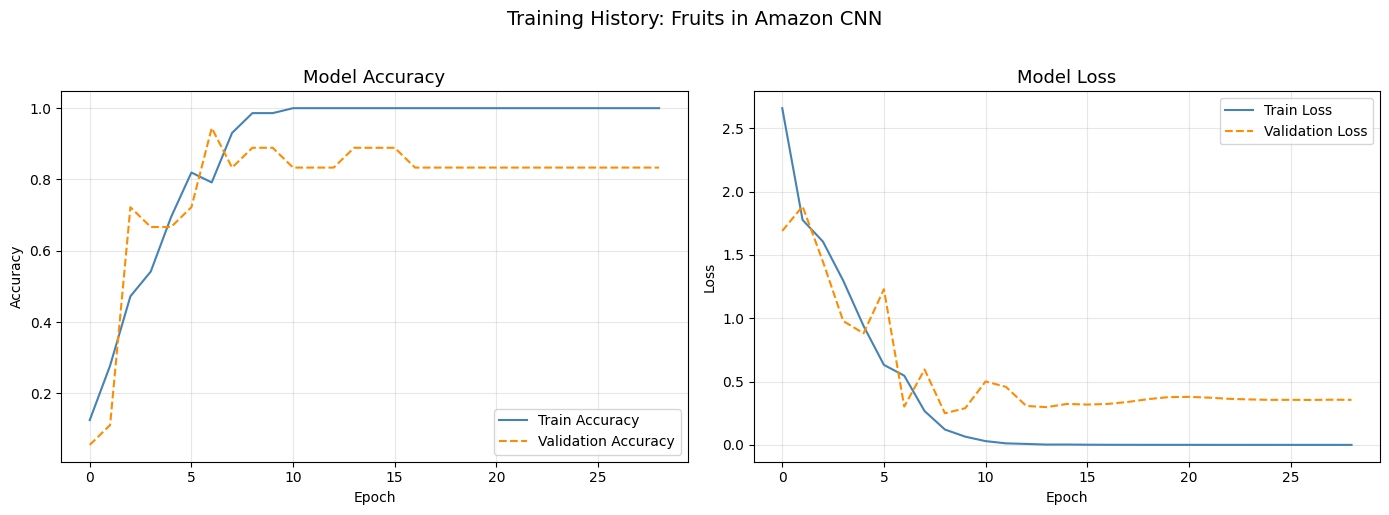

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Accuracy ──────────────────────────────────────────────────────────────────
ax1.plot(history.history["accuracy"], label="Train Accuracy", color="steelblue")
ax1.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy",
    color="darkorange",
    linestyle="--",
)
ax1.set_title("Model Accuracy", fontsize=13)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True, alpha=0.3)

# ── Loss ──────────────────────────────────────────────────────────────────────
ax2.plot(history.history["loss"], label="Train Loss", color="steelblue")
ax2.plot(
    history.history["val_loss"],
    label="Validation Loss",
    color="darkorange",
    linestyle="--",
)
ax2.set_title("Model Loss", fontsize=13)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("Training History: Fruits in Amazon CNN", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### Task 6: Evaluate the Model

**Model Evaluation**

-   After training, evaluate the model using `model.evaluate()` on the test set to check the test accuracy and loss.

In [ ]:
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6333 - loss: 0.8811

Test Loss     : 0.8811
Test Accuracy : 0.6333


### Task 7: Save and Load the Model

**Model Saving and Loading**

-   Save the trained model to an `.h5` file using `model.save()`.

-   Load the saved model and re-evaluate its performance on the test set.

In [ ]:
# ── Save ──────────────────────────────────────────────────────────────────────
model.save("fruits_cnn_final.h5")
print("Model saved → fruits_cnn_final.h5")

# ── Load & Re-evaluate ────────────────────────────────────────────────────────
loaded_model = keras.models.load_model("fruits_cnn_final.h5")
print("Model loaded successfully.")

loaded_loss, loaded_acc = loaded_model.evaluate(test_ds, verbose=1)
print(f"\nLoaded model: Test Loss     : {loaded_loss:.4f}")
print(f"Loaded model: Test Accuracy : {loaded_acc:.4f}")


Model saved → fruits_cnn_final.h5
Model loaded successfully.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6333 - loss: 0.8811 

Loaded model: Test Loss     : 0.8811
Loaded model: Test Accuracy : 0.6333


### Task 8: Predictions and Classification Report

**Making Predictions**

-   Use `model.predict()` to make predictions on test images.

-   Convert the model's predicted probabilities to digit labels using `np.argmax()`.

-   Also use `from sklearn.metrics import classification report` to report the Classification Report of your Model Performance.

In [ ]:
# ── Collect true labels and predictions from the test set ─────────────────────
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = loaded_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("True labels (first 10)     :", y_true[:10])
print("Predicted labels (first 10):", y_pred[:10])


True labels (first 10)     : [0 0 0 0 0 1 1 1 1 1]
Predicted labels (first 10): [0 1 0 0 0 1 1 1 1 1]


In [ ]:
from sklearn.metrics import classification_report

# ── Classification Report ─────────────────────────────────────────────────────
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=2,
)
print("Classification Report\n")
print(report)


Classification Report

              precision    recall  f1-score   support

        acai       0.67      0.80      0.73         5
     cupuacu       0.36      1.00      0.53         5
    graviola       1.00      0.40      0.57         5
     guarana       1.00      0.40      0.57         5
     pupunha       1.00      0.80      0.89         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.63        30
   macro avg       0.84      0.63      0.64        30
weighted avg       0.84      0.63      0.64        30



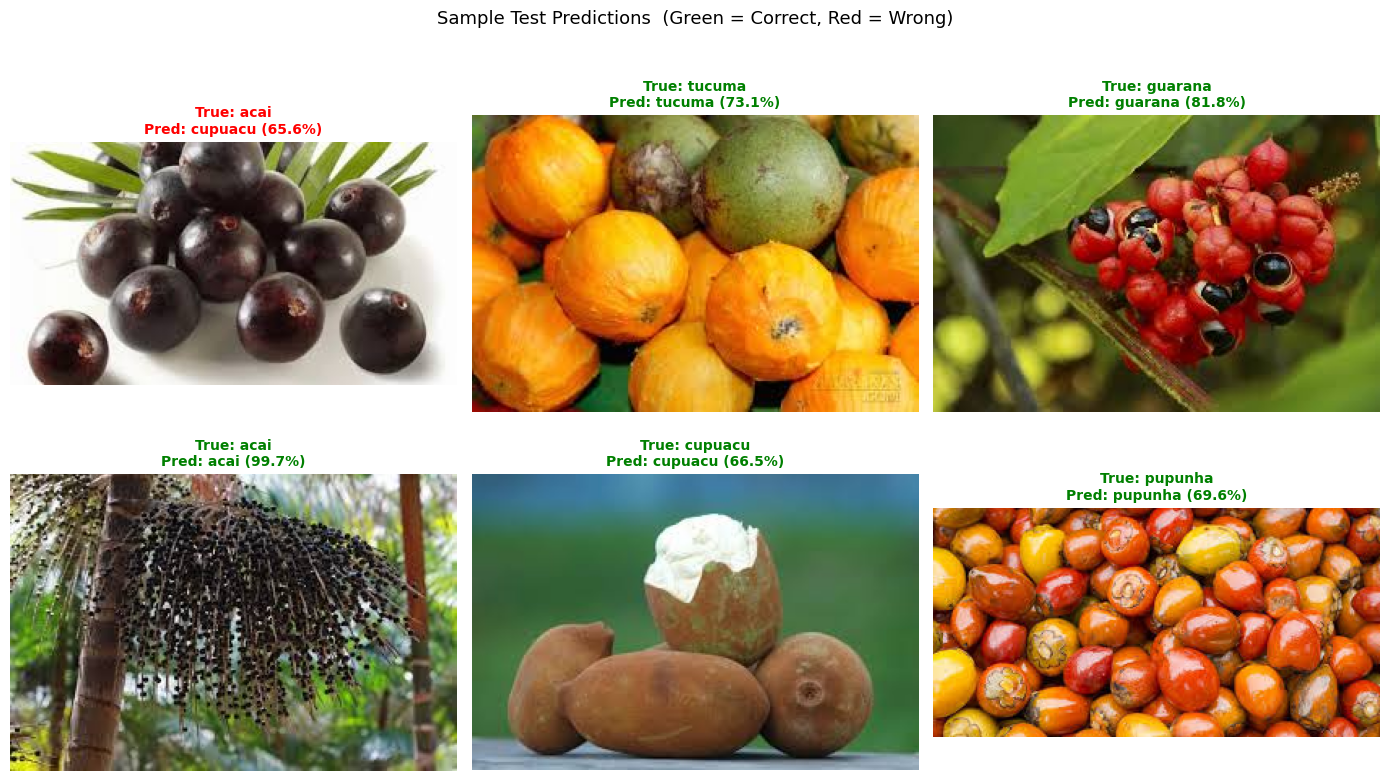

In [ ]:
# ── Visual: Sample Predictions on Test Images ─────────────────────────────────
test_image_paths = []
test_true_labels = []

for cls in sorted(os.listdir(TEST_DIR)):
    cls_path = os.path.join(TEST_DIR, cls)
    if not os.path.isdir(cls_path):
        continue
    for fname in os.listdir(cls_path):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            test_image_paths.append(os.path.join(cls_path, fname))
            test_true_labels.append(cls)

# Pick 6 random test images for display
sample_idx = random.sample(range(len(test_image_paths)), 6)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for plot_idx, img_idx in enumerate(sample_idx):
    img_path = test_image_paths[img_idx]
    true_label = test_true_labels[img_idx]

    # Preprocess for model
    img_tensor = tf.keras.utils.load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    img_array = tf.keras.utils.img_to_array(img_tensor) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred_probs = loaded_model.predict(img_array, verbose=0)
    pred_label = class_names[np.argmax(pred_probs)]
    confidence = np.max(pred_probs) * 100

    color = "green" if pred_label == true_label else "red"
    axes[plot_idx].imshow(mpimg.imread(img_path))
    axes[plot_idx].set_title(
        f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)",
        fontsize=10,
        color=color,
        fontweight="bold",
    )
    axes[plot_idx].axis("off")

plt.suptitle(
    "Sample Test Predictions  (Green = Correct, Red = Wrong)", fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()
